# The Cushing Glut — a quantitative teardown 🔬
### ADF + KPSS · Engle–Granger · bootstrapped sup-F / CUSUM / Bai–Perron · OU half-lives · a real-time fader

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The companion to the [notebook for the curious](01_for_the_curious.ipynb). The load-bearing
results: **§3** (full-sample stationarity fails), **§4** (a mean break at 2010-09,
bootstrap p = 0.002), **§6** (the real-time fader, gross HAC t +1.12) and
**§7** (power: why a level break looks like a unit root).

> ⚠️ **Not investment advice.** Real tape: monthly **spot** Brent and WTI, **calendar-month
> averages** (verified against the daily FRED WTI tape), nominal US$, shipped in `arch` and
> SHA-256 pinned via `quantlab.bundled`. Futures roll yield is **not** in any P&L here —
> every backtest is an **upper bound**. Synthetic cells are labelled *synthetic*.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
BLUE, RED, GREEN, GREY, AMBER = "#1f6feb", "#c0392b", "#2ea44f", "#8b949e", "#b08800"
from cushing import data, strategy as st
px = data.load_crude()
sf = st.spread_frame(px)
print(f"real tape: arch crude, {len(px)} months {px.index[0]:%Y-%m} → {px.index[-1]:%Y-%m}, "
      f"as-of {data.AS_OF}, fingerprint {data.fingerprint(px)}")

real tape: arch crude, 393 months 1987-05 → 2020-01, as-of 2020-01-31, fingerprint 4563b3235b4e


## Verdict, up front (real tape — from [`docs/results.md`](../docs/results.md))

| Axis | Stamp | Decisive numbers |
|---|---|---|
| **Signal** | Weak | full-sample log ratio ADF p = 0.45, KPSS rejects; sup-F break 2010-09 (bootstrap p = 0.002); pre-break half-life 2.7 m (1.9–4.2), pre-break ADF p = 0.066 in logs (< 0.001 in $); real-time fader gross HAC t +1.12, block-bootstrap SR CI −0.09 to +0.38 |
| **Tradability** | Mirage | net +0.94%/yr, SR +0.12, HAC t +0.84 on untradeable spot; frozen pre-2010 trader MAE −23.7% (−25.1 $/bbl), underwater 114 months, never recovered |

The pre-registered rule (`strategy.verdict`) would have read **Mixed** (tethered within regime)
had the pre-break log ratio cleared ADF at 5%; it misses at p = 0.066 — the
pre-break regime carries a smaller shift of its own in the mid-2000s. In dollars it clears
easily. The stamp follows the rule, and the rule reads logs.

> 💡 **In plain words.** The tether was real inside each era and absent across them.

## 1 · Hypotheses (fixed before the run)

- **H₁ (stationary).** The log Brent/WTI ratio is stationary over the full sample (ADF rejects
  *and* KPSS does not).
- **H₂ (no break).** A sup-F scan for a mean shift is insignificant against a persistent,
  break-free AR(1) bootstrap null.
- **H₃ (fade pays).** A z-score fader using only past data (expanding window, ±2σ in, ±0.5σ out,
  one lag) earns a gross HAC t ≥ 2.
- **H₄ (survivable).** Net HAC t ≥ 2, and a trader calibrated on 1987–2009 is underwater ≤ 36
  months.

Real requires H₁–H₃; Mixed requires a break plus a stationary pre-break regime; Fragile
requires H₄. Investable is unreachable on a spot tape by construction.

## 2 · The tape — and why it is not investable

{'n_months': 380, 'median_abs_gap_avg': 0.0024999999999977263, 'share_within_1c_avg': 1.0, 'median_abs_gap_end': 0.9650000000000034, 'is_monthly_average': True}


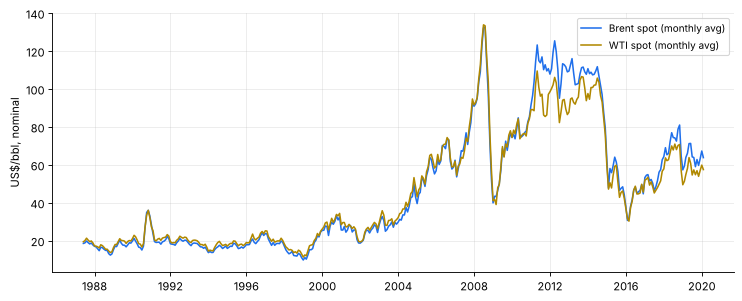

In [2]:
chk = data.check_monthly_average(px)
print(chk)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(px.index, px["brent"], color=BLUE, lw=1.4, label="Brent spot (monthly avg)")
ax.plot(px.index, px["wti"], color=AMBER, lw=1.4, label="WTI spot (monthly avg)")
ax.set_ylabel("US$/bbl, nominal"); ax.legend(fontsize=9)
plt.show()

> 💡 **In plain words.** The monthly WTI number matches the average of daily FRED prints to a
> quarter of a cent — so each point is a month's *average*, a price nobody could deal at. That
> smoothing also adds a little spurious reversion to monthly changes (Working 1960).

## 3 · Stationarity: ADF and KPSS, full sample and sub-samples

In [3]:
b = st.sup_f_mean(sf["log_ratio"])
bd = b["break_date"]
pre_end = (bd - pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")
windows = [("full sample", None, None), ("1987–2003", None, "2003-12-31"),
           ("1987–2009", None, "2009-12-31"), ("pre-break", None, pre_end),
           ("post-break", bd, None), ("2010–2014", "2010-01-31", "2014-12-31"),
           ("2015–2020", "2015-01-31", None)]
stab = st.stationarity_table(sf, windows)
stab[["window", "series", "n", "adf_stat", "adf_p", "kpss_stat", "kpss_p", "reading"]]

,window,series,n,adf_stat,adf_p,kpss_stat,kpss_p,reading
0,full sample,spread,393,-2.479,0.121,1.340,0.010,unit root
1,full sample,log_ratio,393,-1.666,0.449,2.321,0.010,unit root
2,1987–2003,spread,200,-3.787,0.003,0.593,0.023,conflict (both reject)
3,1987–2003,log_ratio,200,-3.603,0.006,0.166,0.100,stationary
4,1987–2009,spread,272,-3.643,0.005,0.165,0.100,stationary
5,1987–2009,log_ratio,272,-2.761,0.064,1.003,0.010,unit root
6,pre-break,spread,280,-8.182,0.000,0.153,0.100,stationary
7,pre-break,log_ratio,280,-2.751,0.066,1.158,0.010,unit root
8,post-break,spread,113,-2.092,0.248,0.731,0.011,unit root
9,post-break,log_ratio,113,-3.063,0.029,0.443,0.059,stationary


In [4]:
eg = pd.DataFrame([{"window": w, **st.engle_granger(px, a, z)} for w, a, z in windows])
eg[["window", "n", "beta", "stat", "p", "reject5"]]

,window,n,beta,stat,p,reject5
0,full sample,393,1.095,-5.519,0.000,True
1,1987–2003,200,1.065,-3.876,0.011,True
2,1987–2009,272,1.044,-7.714,0.000,True
3,pre-break,280,1.045,-7.865,0.000,True
4,post-break,113,1.081,-3.637,0.022,True
5,2010–2014,60,1.180,-2.915,0.132,False
6,2015–2020,61,1.133,-3.773,0.015,True


> 💡 **In plain words.** Over the whole sample the 1:1 spread is not stationary by either test.
> Engle–Granger still rejects no-cointegration on the full sample — but only by choosing a
> slope above one, which is not the claim's "same commodity" spread; over 2010–2014 alone it
> cannot reject at all.

## 4 · Locating the break — by the data, not by hand

### 4.1 sup-F with a bootstrap null

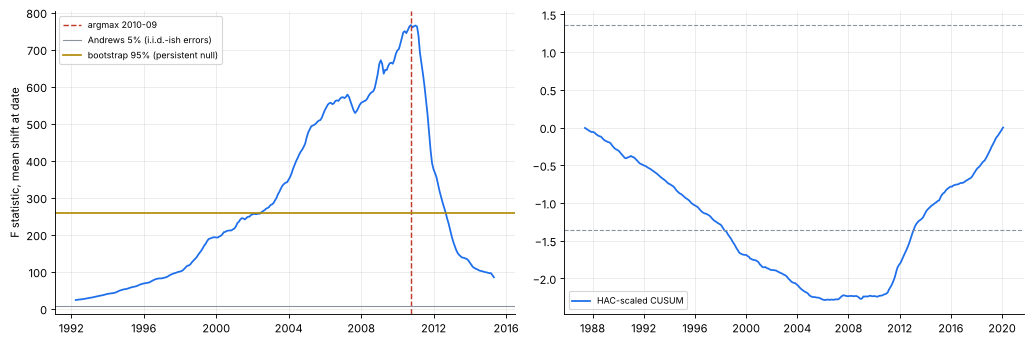

sup-F 766 at 2010-09; bootstrap p 0.005 (null phi 0.937, null 95%/99% 259/500)
CUSUM 2.29 (5% cv 1.358), peak 2006-02


In [5]:
boot = st.sup_f_bootstrap(sf["log_ratio"], n_boot=199)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(b["F_path"].index, b["F_path"], color=BLUE, lw=1.6)
axes[0].axvline(bd, color=RED, ls="--", lw=1.3, label=f"argmax {bd:%Y-%m}")
axes[0].axhline(st.ANDREWS_CV_15["5%"], color=GREY, lw=1, label="Andrews 5% (i.i.d.-ish errors)")
axes[0].axhline(boot["null_q95"], color=AMBER, lw=1.5, label="bootstrap 95% (persistent null)")
axes[0].set_ylabel("F statistic, mean shift at date"); axes[0].legend(fontsize=8)
c = st.cusum_mean(sf["log_ratio"])
axes[1].plot(c["path"].index, c["path"], color=BLUE, lw=1.6, label="HAC-scaled CUSUM")
for s_ in (1, -1):
    axes[1].axhline(s_ * st.CUSUM_CV_5, color=GREY, ls="--", lw=1)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"sup-F {boot['sup_f']:.0f} at {boot['break_date']:%Y-%m}; bootstrap p {boot['p']:.3f} "
      f"(null phi {boot['null_phi']:.3f}, null 95%/99% {boot['null_q95']:.0f}/{boot['null_q99']:.0f})")
print(f"CUSUM {c['stat']:.2f} (5% cv {c['cv5']}), peak {c['peak_date']:%Y-%m}")

> 💡 **In plain words.** A sticky series produces big F statistics by itself, so the
> asymptotic critical value (8.7) is meaningless here; the bootstrap asks how big the biggest
> F gets in a *break-free* world with the same stickiness. The real one (766) is
> larger than almost all of them. (The notebook uses 199 replications for speed; `verify.py`
> uses 499.)

### 4.2 Bai–Perron: several breaks at once

LWZ picks 4 breaks; BIC picks 5


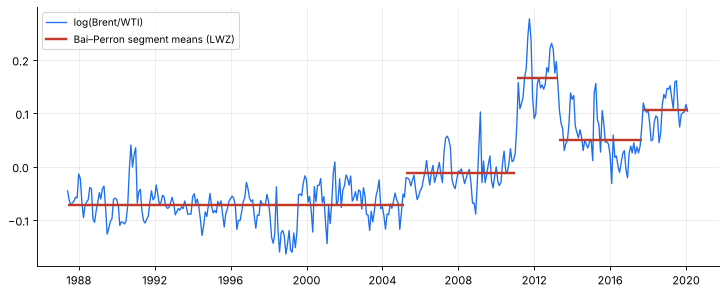

,ssr,lwz,bic,breaks
m,,,,
0,2.750,-4.927,-4.947,
1,0.929,-5.942,-6.002,2010-09
2,0.737,-6.104,-6.203,"2005-03, 2011-01"
3,0.548,-6.330,-6.469,"2005-03, 2011-01, 2013-04"
4,0.491,-6.370,-6.549,"2005-03, 2011-01, 2013-04, 2017-09"
5,0.459,-6.366,-6.585,"2005-03, 2011-01, 2013-04, 2015-09, 2017-09"


In [6]:
bp = st.bai_perron(sf["log_ratio"], max_breaks=5, min_seg=24)
print(f"LWZ picks {bp['m_lwz']} breaks; BIC picks {bp['m_bic']}")
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(sf.index, sf["log_ratio"], color=BLUE, lw=1.2, label="log(Brent/WTI)")
for s_ in bp["segments"]:
    ax.hlines(s_["mean"], s_["start"], s_["end"], color=RED, lw=2.2)
ax.plot([], [], color=RED, lw=2.2, label="Bai–Perron segment means (LWZ)")
ax.legend(fontsize=9); plt.show()
bp["table"]

> 💡 **In plain words.** Information criteria over-count breaks when errors are this
> persistent (the test-suite shows LWZ "finding" breaks in a break-free synthetic tether), so
> the count is descriptive. What every method agrees on is the big shift around 2010/2011.

## 5 · Half-lives before and after

In [7]:
rows = []
for col in ("log_ratio", "spread"):
    t = st.halflife_by_regime(sf[col], [bd]); t.insert(0, "series", col); rows.append(t)
hl = pd.concat(rows, ignore_index=True)
hl["start"] = hl["start"].dt.strftime("%Y-%m"); hl["end"] = hl["end"].dt.strftime("%Y-%m")
hl

,series,start,end,n,mean,sd,phi,halflife,halflife_lo,halflife_hi,adf_p
0,log_ratio,1987-05,2010-08,280,-0.058,0.042,0.773,2.696,1.927,4.226,0.066
1,log_ratio,2010-09,2020-01,113,0.092,0.063,0.847,4.162,2.392,12.201,0.029
2,spread,1987-05,2010-08,280,-1.409,1.244,0.655,1.638,1.215,2.349,0.000
3,spread,2010-09,2020-01,113,7.693,6.476,0.912,7.558,3.897,55.922,0.248


> 💡 **In plain words.** Before the break a stretch halved in ~2.7 months; after, ~4.2
> months around a higher mean, with a band out to 12.2. OLS φ is
> biased down in short samples, so both lean fast. In logs the pre-break ADF p is
> 0.066; in dollars it is < 0.001.

## 6 · The trader's experience — real time, one lag, with costs

In [8]:
rules = {"expanding": st.zscore_realtime(sf["log_ratio"]),
         "rolling 60m": st.zscore_realtime(sf["log_ratio"], window=60),
         "frozen 1987–2009": st.zscore_frozen(sf["log_ratio"])}
rows, books = [], {}
for name, z in rules.items():
    bk = st.book(px, st.positions(z)); books[name] = bk
    g, n = st.perf(bk["gross"], n_boot=500), st.perf(bk["net"], n_boot=500)
    uw = st.underwater(bk["net"], "2010-01-31" if name.startswith("frozen") else None)
    rows.append({"rule": name, "gross /yr": g["ann"], "gross t": g["t_hac"],
                 "SR gross": g["sharpe"], "SR lo": g["sr_lo"], "SR hi": g["sr_hi"],
                 "net /yr": n["ann"], "net t": n["t_hac"], "maxDD": n["maxdd"],
                 "underwater m": uw["months"]})
pd.DataFrame(rows).set_index("rule")

,gross /yr,gross t,SR gross,SR lo,SR hi,net /yr,net t,maxDD,underwater m
rule,,,,,,,,,
expanding,0.013,1.124,0.154,-0.061,0.394,0.009,0.843,-0.284,123
rolling 60m,0.022,2.088,0.311,0.066,0.561,0.019,1.841,-0.184,82
frozen 1987–2009,-0.002,-0.260,-0.037,-0.273,0.187,-0.005,-0.489,-0.264,114


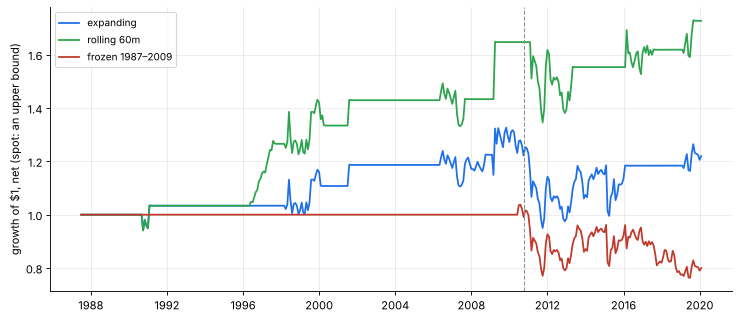

,entry,exit,side,months,net_return,mae,mae_date,usd_pnl,mae_usd,closed,rule
0,1990-08-31,1991-01-31,short spread,5,0.035,-0.059,1990-09-30,1.520,-1.530,True,expanding
1,1998-02-28,2000-01-31,long spread,23,0.073,-0.031,1998-11-30,0.240,-0.500,True,expanding
2,2001-06-30,2001-07-31,short spread,1,0.072,0.000,2001-07-31,2.070,0.000,True,expanding
3,2006-04-30,2008-09-30,short spread,29,0.033,-0.069,2007-05-31,7.700,-2.930,True,expanding
4,2009-01-31,2016-01-31,short spread,84,-0.033,-0.224,2011-09-30,2.710,-25.580,True,expanding
5,2018-12-31,2020-01-31,short spread,13,0.031,-0.017,2019-06-30,1.530,-2.650,False,expanding
0,2010-05-31,2020-01-31,short spread,116,-0.200,-0.237,2019-06-30,-4.100,-25.100,False,frozen


In [9]:
fig, ax = plt.subplots(figsize=(11, 4.6))
for (name, bk), col in zip(books.items(), (BLUE, GREEN, RED)):
    ax.plot(bk.index, (1 + bk["net"]).cumprod(), color=col, lw=1.6, label=name)
ax.axvline(bd, color=GREY, ls="--", lw=1)
ax.set_ylabel("growth of $1, net (spot: an upper bound)"); ax.legend(fontsize=9)
plt.show()
ep = st.episodes(books["frozen 1987–2009"])
pd.concat([st.episodes(books["expanding"]).assign(rule="expanding"), ep.assign(rule="frozen")])

> 💡 **In plain words.** The expanding-window fader's worst trade opened in 2009-01
> and was down −22.4% (−25.6 $/bbl) at the 2011-09 peak of the
> glut. The frozen pre-2010 trader went short in 2010-05 and was still in the trade,
> −20.0% net, when the tape ended 114 months into its drawdown. The
> rolling window looks best (gross t +2.09) because it forgets faster — but it is
> one of many windows, chosen with hindsight, and still below 2 net.

In [10]:
cs = st.cost_sweep(px, st.positions(rules["expanding"]))
print("break-even one-way cost per leg (bp):",
      round(st.break_even_cost(px, st.positions(rules["expanding"]))))
sub = []
for lab, a, z in [("1987–2009", None, "2009-12-31"), ("2010–2014", "2010-01-31", "2014-12-31"),
                  ("2015–2020", "2015-01-31", None)]:
    bk = st._window(books["expanding"], a, z)
    sub.append({"period": lab, "gross t": st.perf(bk["gross"], n_boot=200)["t_hac"],
                "net t": st.perf(bk["net"], n_boot=200)["t_hac"]})
display(cs); pd.DataFrame(sub).set_index("period")

break-even one-way cost per leg (bp): 144


,ann,sharpe,t_hac
cost_bps,,,
0,0.010,0.119,0.871
2,0.010,0.118,0.860
5,0.009,0.115,0.843
10,0.009,0.111,0.814
20,0.008,0.103,0.757
40,0.007,0.086,0.639


,gross t,net t
period,,
1987–2009,1.467,1.264
2010–2014,-0.111,-0.243
2015–2020,0.661,0.548


> 💡 **In plain words.** Costs are not what kills it — the break-even cost is large because
> the rule trades rarely. What kills it is that the edge itself is thin (t ≈ 1) and the losses
> concentrate in one episode the rule could not see coming. With n ≈ 390 months and six
> round-trips, the sample simply cannot certify a mean-reversion premium.

## 7 · Power — what n = 393 can see (synthetic)

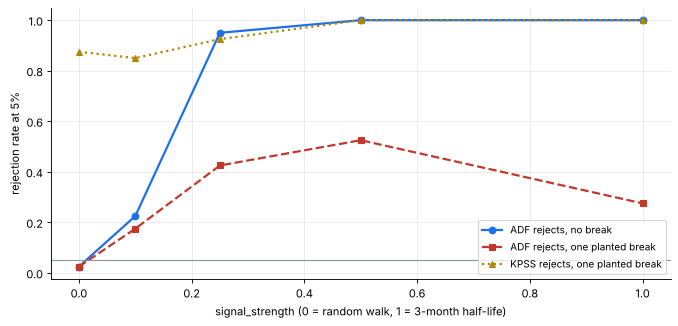

,halflife,adf_reject,kpss_reject,halflife_break,adf_reject_break,kpss_reject_break
signal_strength,,,,,,
0.000,inf,0.025,0.925,inf,0.025,0.875
0.100,30.000,0.225,0.650,30.000,0.175,0.850
0.250,12.000,0.950,0.350,12.000,0.425,0.925
0.500,6.000,1.000,0.250,6.000,0.525,1.000
1.000,3.000,1.000,0.125,3.000,0.275,1.000


In [11]:
# SYNTHETIC: OU log ratios calibrated to the pre-break regime (half-life 3 m at strength 1)
pw = st.power_curve(strengths=(0.0, 0.1, 0.25, 0.5, 1.0), n_reps=40)
pwb = st.power_curve(strengths=(0.0, 0.1, 0.25, 0.5, 1.0), n_reps=40, break_size=0.15)
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(pw.index, pw["adf_reject"], "o-", color=BLUE, lw=2, label="ADF rejects, no break")
ax.plot(pwb.index, pwb["adf_reject"], "s--", color=RED, lw=2, label="ADF rejects, one planted break")
ax.plot(pwb.index, pwb["kpss_reject"], "^:", color=AMBER, lw=2, label="KPSS rejects, one planted break")
ax.axhline(0.05, color=GREY, lw=1)
ax.set_xlabel("signal_strength (0 = random walk, 1 = 3-month half-life)")
ax.set_ylabel("rejection rate at 5%"); ax.legend(fontsize=9)
plt.show()
pw.join(pwb.add_suffix("_break"))

> 💡 **In plain words.** At this sample length ADF finds a three-month tether every time — so
> the real full-sample failure is not a power problem. But plant one level shift the size of
> the real one and ADF mostly stops rejecting while KPSS rejects nearly always: exactly the
> real tape's signature. A broken tether *looks like* no tether (Perron 1989).

In [12]:
# SYNTHETIC: the break test itself — quiet without a break, loud with one
for bsz in (0.0, 0.15):
    spx, tr = data.synthetic_spread(signal_strength=1.0, break_size=bsz, seed=7)
    q = st.sup_f_bootstrap(np.log(spx["brent"] / spx["wti"]), n_boot=199)
    print(f"planted break {bsz:.2f}: bootstrap p = {q['p']:.3f}, located {q['break_date']:%Y-%m}"
          f" (true {tr['break_date']:%Y-%m})" if bsz else
          f"planted break {bsz:.2f}: bootstrap p = {q['p']:.3f}")
tp = st.synthetic_trade_power(strengths=(0.0, 0.5, 1.0), n_reps=20)
tp

planted break 0.00: bootstrap p = 0.425
planted break 0.15: bootstrap p = 0.005, located 2010-11 (true 2010-11)


,median_t,share_t_ge_2
signal_strength,,
0.000,-0.000,0.000
0.500,2.581,0.800
1.000,3.341,0.950


## 8 · The verdict

**Signal: Weak.** H₁ fails (full-sample ADF p = 0.45, KPSS rejects). H₂
fails (break at 2010-09, bootstrap p = 0.002; the dollar spread's mean moved
from −1.41 to +7.69 $/bbl). H₃ fails (gross HAC t +1.12,
block-bootstrap SR CI −0.09 to +0.38). The Mixed branch misses narrowly in logs. There is
mean reversion here — fast, within each regime — but the claim's "always" is what the tape
rejects.

**Tradability: Mirage.** H₄ fails on both legs: net t +0.84 and 114
months underwater for the pre-2010 believer, on a tape that flatters the trade (spot, monthly
averages, no roll yield).

## 9 · Could you trade it?

The executable version is a calendar-matched ICE Brent vs NYMEX WTI futures spread (or the
exchange-listed Brent–WTI spread contracts). Per-leg transaction costs are small and barely
matter (see the cost sweep). The roll does: from 2009 to 2011 the WTI curve was in deep
contango as Cushing filled, so the fader's long-WTI leg paid to roll every month on top of the
spot loss. Capacity is not the binding constraint — both legs are among the deepest commodity
futures in the world. The binding constraint is that the anchor is infrastructure, and
infrastructure changed.

## 10 · Going further

- **Futures-based rebuild** with actual roll yields — the obvious next PR.
- **A moving anchor.** Model the mean as a function of Cushing inventories or pipeline capacity
  (EIA data) and test whether reversion to *that* is stable — the honest form of the claim.
- **Daily data** would raise n and the power of every test here; the bundled daily tape has WTI
  only, so it is not attempted.
- **Regime-switching nulls** for the break bootstrap (heavier tails, volatility regimes) would
  widen the null; the AR(1) null used here is the simplest defensible one.